# Data Cleaning Exercise

Cleaning your data is crucial when starting a new data engineering project because it ensures the accuracy, consistency, and reliability of the dataset. Dirty data, which may include duplicates, missing values, and errors, can lead to incorrect analysis and insights, ultimately affecting the decision-making process. Data cleaning helps in identifying and rectifying these issues, providing a solid foundation for building effective data models and analytics. Additionally, clean data improves the performance of algorithms and enhances the overall efficiency of the project, leading to more trustworthy and actionable results.

Use Python, ```numpy```, ```pandas``` and/or ```matplotlib``` to analyse and clean your batch data:

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data



In [2]:
df = pd.read_csv("../data/raw/tesla_stock_data_raw.csv")

df.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-02,28.3000,28.7130,28.1140,28.6840,143375790
1,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455
2,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485
3,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070
4,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895


## Understand the Data

View the first few rows, get summary statistics and check data types

In [3]:
print("First rows:")
display(df.head())

print("Dataset shape:")
print(df.shape)

print("Dataset information:")
df.info()

print("Summary statistics:")
display(df.describe())

print("Column names:")
print(df.columns)

First rows:


,Date,Open,High,Low,Close,Volume
0,2020-01-02,28.3000,28.7130,28.1140,28.6840,143375790
1,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455
2,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485
3,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070
4,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895


Dataset shape:
(1589, 6)
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1589 non-null   object 
 1   Open    1589 non-null   float64
 2   High    1589 non-null   float64
 3   Low     1589 non-null   float64
 4   Close   1589 non-null   float64
 5   Volume  1589 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 74.6+ KB
Summary statistics:


,Open,High,Low,Close,Volume
count,1589.000000,1589.000000,1589.000000,1589.000000,1.589000e+03
mean,245.706333,251.123827,239.997144,245.619048,1.180290e+08
std,101.887544,103.669025,99.795448,101.684587,7.616858e+07
min,24.979700,26.990700,23.367300,24.081300,2.940167e+07
25%,185.480000,189.320000,182.000000,185.900000,7.211069e+07
50%,239.290000,245.220000,234.010000,239.057000,9.717108e+07
75%,307.930000,314.283000,301.070000,308.720000,1.342288e+08
max,489.880000,498.830000,485.330000,489.880000,9.140814e+08


Column names:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


## Handle Missing Data

Identify missing values and fill or drop missing values

In [4]:
print("Missing values before cleaning:")
display(df.isnull().sum())

df = df.dropna()

print("Missing values after cleaning:")
display(df.isnull().sum())

print("Shape after removing missing values:", df.shape)

Missing values before cleaning:


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Missing values after cleaning:


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Shape after removing missing values: (1589, 6)


## Handle Duplicates

Identify duplicates and remove them

In [5]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows before cleaning:", duplicates)

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()
print("Number of duplicate rows after cleaning:", duplicates_after)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows before cleaning: 0
Number of duplicate rows after cleaning: 0
Shape after removing duplicates: (1589, 6)


## Handle Outliers

Identify outliers and remove or corret them

Daily return statistics:


count    1588.000000
mean        0.002462
std         0.041220
min        -0.210628
25%        -0.020130
50%         0.001599
75%         0.022820
max         0.226900
Name: Daily_Return, dtype: float64

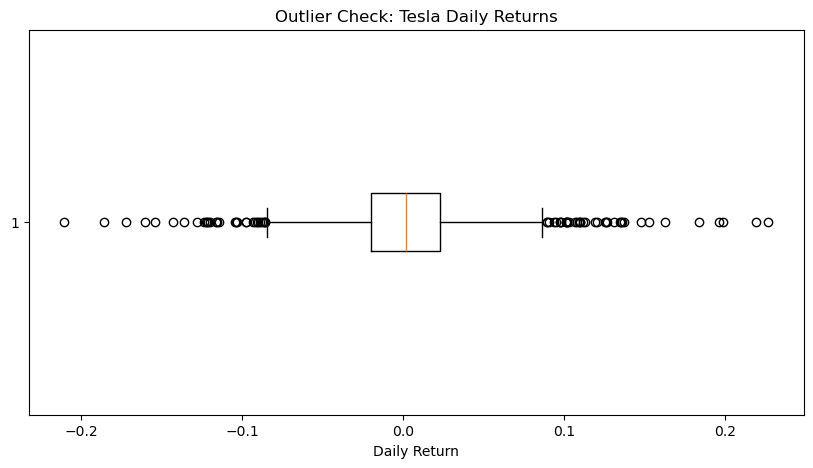

Extreme daily returns greater than 15%:


,Date,Close,Daily_Return
21,2020-02-03,52.0000,0.198985
23,2020-02-05,48.9800,-0.171750
50,2020-03-16,29.6713,-0.185749
52,2020-03-18,24.0813,-0.160345
53,2020-03-19,28.5093,0.183877
56,2020-03-24,33.6667,0.162817
172,2020-09-08,110.0700,-0.210628
297,2021-03-09,224.5270,0.196412
1087,2024-04-29,194.0500,0.153069
1211,2024-10-24,260.4800,0.219190


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df["Daily_Return"] = df["Close"].pct_change()

print("Daily return statistics:")
display(df["Daily_Return"].describe())

plt.figure(figsize=(10, 5))
plt.boxplot(df["Daily_Return"].dropna(), vert=False)
plt.title("Outlier Check: Tesla Daily Returns")
plt.xlabel("Daily Return")
plt.show()

extreme_returns = df[df["Daily_Return"].abs() > 0.15]

print("Extreme daily returns greater than 15%:")
display(extreme_returns[["Date", "Close", "Daily_Return"]].head(10))

## Handle Incorrect Data Types

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna()

df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0) &
    (df["Volume"] >= 0)
]

df = df.sort_values("Date")

df["Daily_Return"] = df["Close"].pct_change()
df["Price_Range"] = df["High"] - df["Low"]

print("Data types after cleaning:")
df.info()

print("Shape after fixing data types and invalid values:", df.shape)

display(df.head())

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 1588 entries, 1 to 1588
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1588 non-null   datetime64[ns]
 1   Open          1588 non-null   float64       
 2   High          1588 non-null   float64       
 3   Low           1588 non-null   float64       
 4   Close         1588 non-null   float64       
 5   Volume        1588 non-null   int64         
 6   Daily_Return  1587 non-null   float64       
 7   Price_Range   1588 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 111.7 KB
Shape after fixing data types and invalid values: (1588, 8)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range
1,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455,NaN,1.1387
2,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485,0.019256,0.7707
3,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070,0.038801,1.2183
4,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895,0.049203,2.0180
5,2020-01-09,33.1400,33.2533,31.5247,32.0893,426947790,-0.021945,1.7286


## Visualize Data

Use graphes, plots and/or diagrams to visualize the data

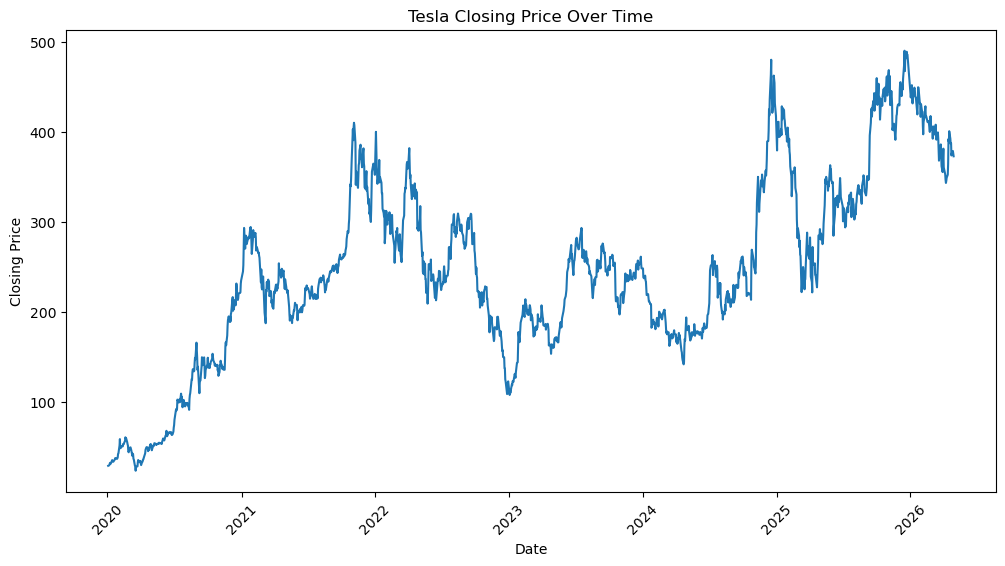

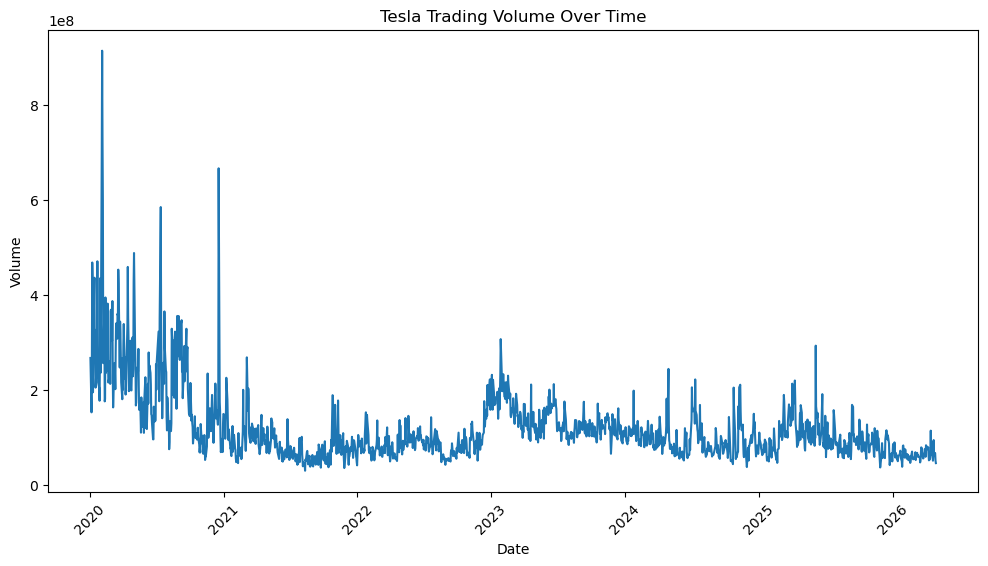

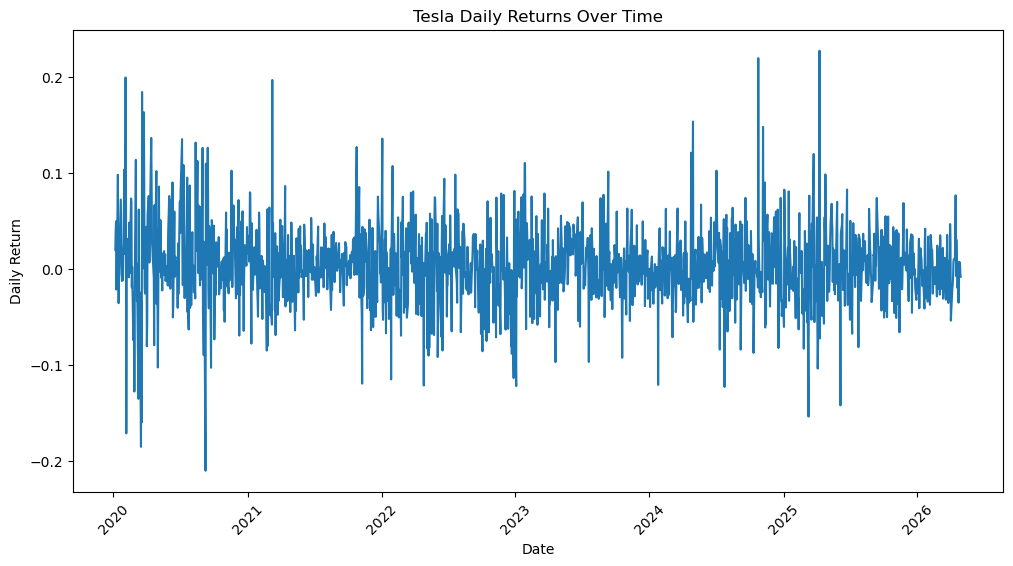

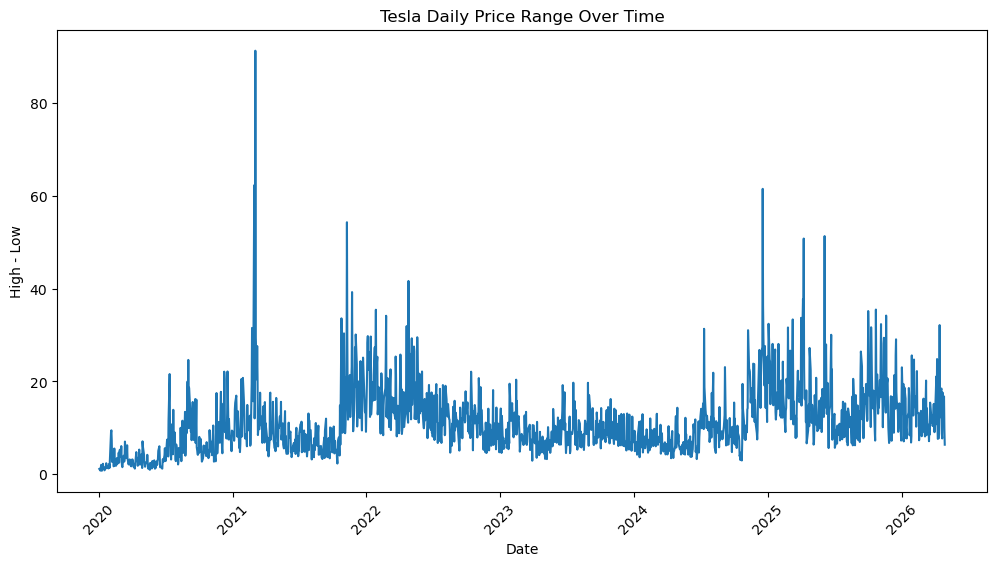

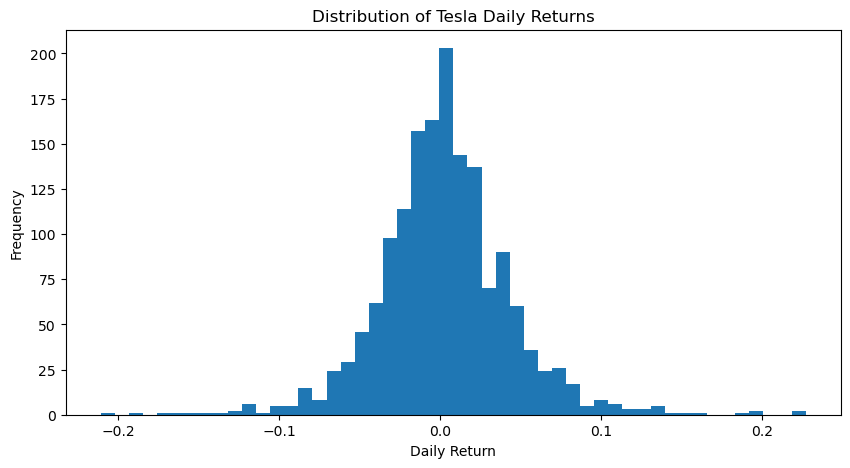

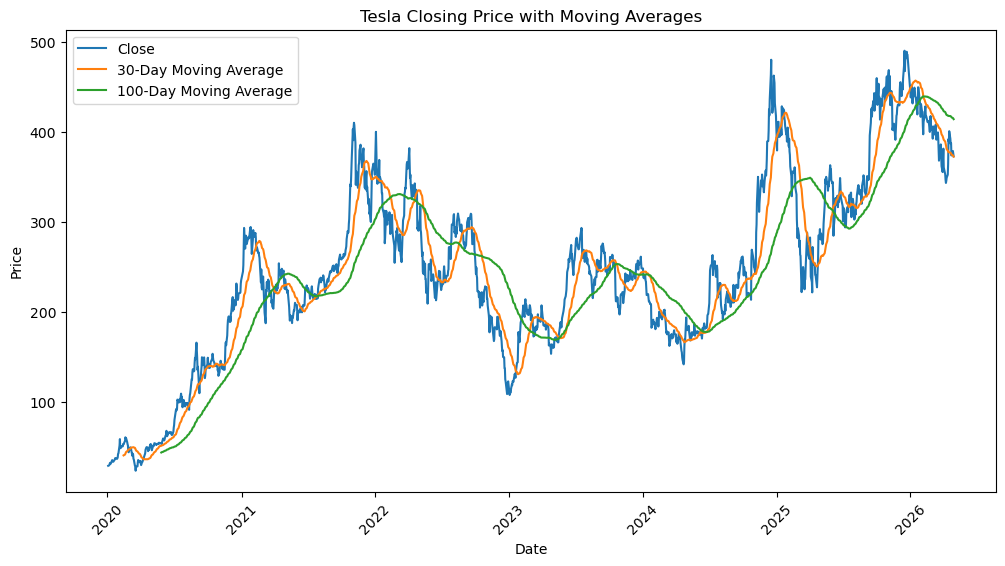

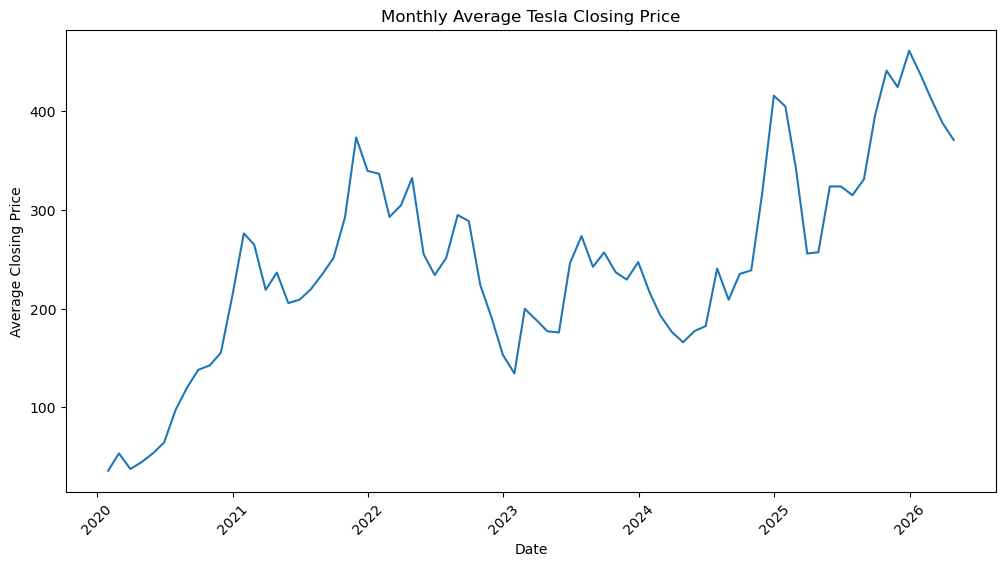

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Volume"])
plt.title("Tesla Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Daily_Return"])
plt.title("Tesla Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Price_Range"])
plt.title("Tesla Daily Price Range Over Time")
plt.xlabel("Date")
plt.ylabel("High - Low")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["Daily_Return"].dropna(), bins=50)
plt.title("Distribution of Tesla Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

df["MA_30"] = df["Close"].rolling(window=30).mean()
df["MA_100"] = df["Close"].rolling(window=100).mean()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average")
plt.plot(df["Date"], df["MA_100"], label="100-Day Moving Average")
plt.title("Tesla Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.show()

monthly_close = df.set_index("Date")["Close"].resample("M").mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_close.index, monthly_close.values)
plt.title("Monthly Average Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=45)
plt.show()

## Save Cleaned Data

In [9]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/tesla_stock_data_cleaned.csv", index=False)

print("Cleaned dataset saved as ../data/processed/tesla_stock_data_cleaned.csv")
print("Final dataset shape:", df.shape)

Cleaned dataset saved as ../data/processed/tesla_stock_data_cleaned.csv
Final dataset shape: (1588, 10)
